# Laboratorio 5.1: Adaptación a PyTorch de Modelos de Regresión
**Autor:** Valencia Medina Freddy D.  
**Base de datos:** Lending Club — Accepted Loans 2007-2018 Q4  
**Objetivo de esta fase:** reutilizar el preprocesamiento de laboratorios anteriores y construir una versión en PyTorch con `nn.Module`, `Dataset/DataLoader` y `checkpoints` reproducibles.


In [1]:
# Librerias base
import os
import time
import json
import numpy as np
import pandas as pd
from matplotlib import pyplot
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Escaner rutas de Kaggle
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv
/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydaniel-regresionlineal/X_test_norm.npy
/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydaniel-regresionlineal/y_train.npy
/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydaniel-regresionlineal/y_test.npy
/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydaniel-regresionlineal/__results__.html
/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydaniel-regresionlineal/sigma.npy
/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydanie

In [2]:
# ruta del dataset
t0_carga_dataset = time.time()
ruta_dataset = '/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz'
# usamos la funcion de pandas read_csv, usamos gzip porque el dataset esta comprimido
# low_memory = False es debido a la inconsistencia en los tipos de las columnas
df_raw = pd.read_csv(ruta_dataset, compression='gzip', low_memory=False)
elapsed_carga_dataset = time.time() - t0_carga_dataset

# imprimimos el atributo shape de nuestro dataset para saber las filas y columnas
print('shape original: ', df_raw.shape)
print(f'Tiempo de carga de dataset: {elapsed_carga_dataset:.2f} s')

shape original:  (2260701, 151)
Tiempo de carga de dataset: 75.12 s


## Exploración inicial — Análisis de valores nulos
Calculamos el **porcentaje de nulos por columna** con la fórmula:

$$\text{%\ nulos}_j = \frac{\sum_{i=1}^{m} \mathbb{1}[x_{ij} = \text{NaN}]}{m} \times 100$$

Esto nos permite decidir qué columnas conservar (< 30 % nulos), cuáles imputar y cuáles eliminar.

In [3]:
#extraemos solamente los encabezados de cada columna y usamos la funcion .tolist()
#esto nos permite  convertir el formato de Index  a una lista y la imprimimos
print(df_raw.columns.tolist())
#usadmos la funcion set_option para que nos muestre todas las filas y no las abrevie

pd.set_option('display.max_rows',None)

#usamos la funcion .isnull() para poder obtener todos los nulos y luego con .sum()
#obtenemos el numero total de nulos por columna esto lo dividimos entre el largo de toda la tabla
# es decir las filas  de esta  manera sacamos la proporcion de nulos en cada fila
# lo multiplicamos por 100 para poder obtener el porcentaje de nulso por columna
print(df_raw.isnull().sum() / len(df_raw)*100)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

## Manjeo de características

Transformamos columnas de texto en numéricas para que el modelo las procese:

| Columna original | Transformación | Resultado |
|---|---|---|
| `term` | `" 36 months"` → `36.0` | Numérica continua |
| `earliest_cr_line` | `"Jan-2005"` → años desde 2018-12-31 | `credit_history_years` (float) |
| `home_ownership` | One-hot encoding manual | `home_ownership_OWN`, `home_ownership_MORTGAGE` (binarias) |
| `verification_status` | One-hot encoding manual | `verification_status_Source Verified`, `verification_status_Verified` (binarias) |

> **Nota sobre variables dummy:** Para $k$ categorías se crean $k-1$ columnas binarias. La categoría omitida (RENT, Not Verified) queda representada cuando todas las dummies valen 0. Esto evita la multicolinealidad

In [4]:
# Copiamos el dataset para no modificar el original aunque ocupa el doble de memoria
# nos da un seguro en caso nos equivoquemos al limpiar datos
df = df_raw.copy()

# Convertir term (plazo) a float reemplazando el acompanamientos de meses usando 

if df['term'].dtype == object:
    df['term'] = df['term'].str.replace(' months', '').astype(float)
else:
    df['term'] = df['term'].astype(float)

# earliest_cr_line texto (Jan-2005) lo convertimos a años de historial crediticio
#para poder usarlo con el gradiente descendente  lo convertimos a un numero restando de la fecha en 
#la que acaban los prestamos dle dataset  menos la fecha del cliente
df['credit_history_years'] = (
    pd.to_datetime('2018-12-31') - pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
).dt.days / 365

# Hacemos las variables ficticias para home inicialmente texto con las posibles respuestas
# RENT OWN MORTAGE donde  ahora sera binaria en cada columna
df['home_ownership_OWN']      = (df['home_ownership'] == 'OWN').astype(int)
df['home_ownership_MORTGAGE'] = (df['home_ownership'] == 'MORTGAGE').astype(int)

# hacemos las variables ficiticas para el estado de verificacione misma logica que arriba
# Verified Not Verified SourceVerified
df['verification_status_Source Verified'] = (df['verification_status'] == 'Source Verified').astype(int)
df['verification_status_Verified']        = (df['verification_status'] == 'Verified').astype(int)

#imprimimos mensajes de confimarcion para ver que todo salio bien y confirmamos
#que el tipo de term y el de credit  son numeros
print('Conversiones realizadas')
print('term dtype:', df['term'].dtype)
print('credit_history_years dtype:', df['credit_history_years'].dtype)

Conversiones realizadas
term dtype: float64
credit_history_years dtype: float64


In [5]:
# Tras el análisis, elegimos columnas relacionadas con lo que queremos predecir.
# Eliminamos columnas que causen fuga de datos, tengan +30% nulos, o sean redundantes.
# Eliminamos 3 columnas por multicolinealidad (ver README):
#   - fico_range_high: correlación ~1.0 con fico_range_low (siempre es fico_low + 4)
#   - avg_cur_bal: redundante con tot_cur_bal (promedio = total / num_cuentas)
#   - num_sats: casi idéntico a open_acc (cuentas satisfactorias ≈ cuentas abiertas)
# Nos quedamos con 51 columnas predictoras.
columnas_x = [
    'loan_amnt', 'term',
    'home_ownership_OWN', 'home_ownership_MORTGAGE',
    'verification_status_Source Verified', 'verification_status_Verified',
    'annual_inc', 'dti',
    'fico_range_low',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc',
    'pub_rec', 'revol_bal', 'revol_util',
    'tot_cur_bal', 'total_rev_hi_lim',
    'total_il_high_credit_limit', 'total_bc_limit',
    'bc_open_to_buy', 'total_bal_ex_mort', 'bc_util',
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'delinq_amnt', 'acc_open_past_24mths', 'acc_now_delinq',
    'tot_coll_amt', 'chargeoff_within_12_mths',
    'pub_rec_bankruptcies', 'tax_liens',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
    'mths_since_recent_bc', 'mths_since_recent_inq', 'mort_acc',
    'num_tl_op_past_12m', 'num_accts_ever_120_pd', 'num_tl_120dpd_2m',
    'num_tl_90g_dpd_24m', 'num_tl_30dpd',
    'num_actv_bc_tl', 'num_actv_rev_tl', 'num_op_rev_tl',
    'num_bc_tl', 'num_il_tl',
    'num_rev_accts', 'num_rev_tl_bal_gt_0',
    'credit_history_years',
]
# Esta será la columna que queremos predecir con nuestra regresión
columna_y = 'int_rate'

# Sobreescribimos nuestra variable con los datos útiles
df = df[columnas_x + [columna_y]]

print('Shape tras selección:', df.shape)
print(f'Variables predictoras: {len(columnas_x)}')

Shape tras selección: (2260701, 52)
Variables predictoras: 51


## Manejo de valores nulos (Imputación y eliminación)



| Columna | % Nulos (~) | Acción | Justificación |
|---|---|---|---|
| `mths_since_recent_inq` | ~15 % | Imputar con **mediana** | Eliminar tantas filas perdería ~300 k ejemplos |
| `num_tl_120dpd_2m` | ~15 % | Imputar con **mediana** | Misma razón |
| Resto (~3 %) | ~3 % | Eliminar filas | Cantidad insignificante, no distorsiona la distribución |

In [6]:
# Columnas con aporox (15%) de nulos imputamos con mediana para no eliminar
#300000 filas colocando el valor mas tipico en las filas vacias 

# mths_since_recent_inq: Meses desde la última vez que el cliente pidió crédito.
# num_tl_120dpd_2m: Número de cuentas con más de 120 días de atraso.
df['mths_since_recent_inq'] = df['mths_since_recent_inq'].fillna(df['mths_since_recent_inq'].median())
df['num_tl_120dpd_2m']      = df['num_tl_120dpd_2m'].fillna(df['num_tl_120dpd_2m'].median())

# Resto de nulos alrededor de ( 3%) eliiminamos las filas no es una cifra
#significante entonces en lugar de imputarlas elimnasmos las filas 
print('Filas antes:', len(df_raw))
df.dropna(inplace=True)
print('Filas después:', len(df))
print('Filas eliminadas:', len(df_raw) - len(df))
print('Nulos restantes:', df.isnull().sum().sum())

Filas antes: 2260701
Filas después: 2162365
Filas eliminadas: 98336
Nulos restantes: 0


In [7]:
print(df.isnull().sum() / len(df) * 100)

loan_amnt                              0.0
term                                   0.0
home_ownership_OWN                     0.0
home_ownership_MORTGAGE                0.0
verification_status_Source Verified    0.0
verification_status_Verified           0.0
annual_inc                             0.0
dti                                    0.0
fico_range_low                         0.0
delinq_2yrs                            0.0
inq_last_6mths                         0.0
open_acc                               0.0
total_acc                              0.0
pub_rec                                0.0
revol_bal                              0.0
revol_util                             0.0
tot_cur_bal                            0.0
total_rev_hi_lim                       0.0
total_il_high_credit_limit             0.0
total_bc_limit                         0.0
bc_open_to_buy                         0.0
total_bal_ex_mort                      0.0
bc_util                                0.0
pct_tl_nvr_

In [8]:
# Extraemos las columnas de entrenamiento y el objetivo
X_all = df[columnas_x].values
y_all = df[columna_y].values

# SPLIT TRAIN / TEST (80% / 20%)
# Usamos una semilla para reproducibilidad
np.random.seed(42)
indices = np.random.permutation(len(y_all))
split = int(0.8 * len(y_all))

X_train = X_all[indices[:split]]
y_train = y_all[indices[:split]]
X_test  = X_all[indices[split:]]
y_test  = y_all[indices[split:]]

m_train = y_train.size
m_test  = y_test.size

print(f'Total de ejemplos: {len(y_all)}')
print(f'Entrenamiento: {m_train}  ({m_train/len(y_all)*100:.1f}%)')
print(f'Test:          {m_test}  ({m_test/len(y_all)*100:.1f}%)')
print(f'Número de características n: {X_train.shape[1]}')

Total de ejemplos: 2162365
Entrenamiento: 1729892  (80.0%)
Test:          432473  (20.0%)
Número de características n: 51


In [9]:
display(X_all[:5])
X_all.shape

array([[3.60000000e+03, 3.60000000e+01, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 5.50000000e+04, 5.91000000e+00,
        6.75000000e+02, 0.00000000e+00, 1.00000000e+00, 7.00000000e+00,
        1.30000000e+01, 0.00000000e+00, 2.76500000e+03, 2.97000000e+01,
        1.44904000e+05, 9.30000000e+03, 1.37340000e+04, 2.40000000e+03,
        1.50600000e+03, 7.74600000e+03, 3.72000000e+01, 7.69000000e+01,
        0.00000000e+00, 0.00000000e+00, 4.00000000e+00, 0.00000000e+00,
        7.22000000e+02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.28000000e+02, 3.00000000e+00, 3.00000000e+00, 4.00000000e+00,
        4.00000000e+00, 1.00000000e+00, 3.00000000e+00, 2.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.00000000e+00,
        4.00000000e+00, 4.00000000e+00, 5.00000000e+00, 3.00000000e+00,
        9.00000000e+00, 4.00000000e+00, 1.54273973e+01],
       [2.47000000e+04, 3.60000000e+01, 0.00000000e+00, 1.00000000e+00,
       

(2162365, 51)

## Normalización de características (Feature Scaling)

Para que el gradiente descendente converja eficientemente, normalizamos cada variable
$$x_j^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

Donde:
- $\mu_j$ = media de la columna $j$ → Centra los datos en 0.
- $\sigma_j$ = desviación estándar de la columna $j$ → Escala los datos a varianza unitaria.


In [10]:
def featureNormalize(X):
    # Calculamos la media y desviación estándar de cada columna
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Si alguna columna tiene sigma=0 (constante), ponemos 1 para evitar división por cero
    sigma[sigma == 0] = 1
    
    # Normalizamos: (x - media) / desviación
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

print('Funcion featureNormalize creada correctamente')

Funcion featureNormalize creada correctamente


In [11]:
# Normalizamos solo con los datos de entrenamiento
# mu y sigma se calculan del train y se aplican también al test
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicamos la misma mu y sigma al conjunto de test 
X_test_norm = (X_test - mu) / sigma

print('Media calculada (mu) de las 51 columnas (del train):')
print(mu) 
print('\nDesviación estándar calculada (sigma) de las 51 columnas (del train):')
print(sigma)

print('\nMatriz de entrenamiento normalizada (primeras 3 filas):')
print(X_train_norm[:3])


Media calculada (mu) de las 51 columnas (del train):
[1.51823974e+04 4.29640556e+01 1.13027865e-01 4.92746946e-01
 3.96603950e-01 2.76398758e-01 7.84728147e+04 1.89759905e+01
 6.98238008e+02 3.09685807e-01 5.65623750e-01 1.17287692e+01
 2.42650402e+01 2.02264072e-01 1.68442685e+04 5.03050301e+01
 1.42632311e+05 3.48365496e+04 4.37428667e+04 2.35010907e+04
 1.14251945e+04 5.12493561e+04 5.78472499e+01 9.41567731e+01
 4.23432854e+01 1.28587762e+01 4.54037882e+00 4.26847456e-03
 2.35636216e+02 8.72771248e-03 1.30991414e-01 4.83700717e-02
 1.81623317e+02 1.38702040e+01 8.25940232e+00 2.47154210e+01
 6.80031701e+00 1.55575608e+00 2.08347862e+00 4.97876168e-01
 6.11020804e-04 8.22912644e-02 2.79959674e-03 3.72008310e+00
 5.67088408e+00 8.30444675e+00 7.78665605e+00 8.39878212e+00
 1.40668001e+01 5.61893517e+00 1.90016420e+01]

Desviación estándar calculada (sigma) de las 51 columnas (del train):
[9.20827111e+03 1.08921652e+01 3.16626858e-01 4.99947390e-01
 4.89192454e-01 4.47216373e-01 1.216

In [12]:
# Guarda todo lo necesario para la Fase GPU
import json, numpy as np

np.save('/kaggle/working/X_train_norm.npy', X_train_norm)
np.save('/kaggle/working/X_test_norm.npy',  X_test_norm)
np.save('/kaggle/working/y_train.npy',      y_train)
np.save('/kaggle/working/y_test.npy',       y_test)
np.save('/kaggle/working/mu.npy',           mu)
np.save('/kaggle/working/sigma.npy',        sigma)

with open('/kaggle/working/columnas_x.json', 'w') as f:
    json.dump(columnas_x, f)

print("Checkpoint 1 guardado")

Checkpoint 1 guardado


In [14]:
# A partir de aqui ya usamos la gpu 

import numpy as np
import json
import torch
import torch.nn as nn
from matplotlib import pyplot
import time
import json
from torch.utils.data import Dataset, DataLoader

t0_carga_checkpoint = time.time()

# Ruta praa recupera los datos preprocesados
RUTA = '/kaggle/input/notebooks/freddyvalenciamedina/lab5-1-valenciamedinafreddydaniel-regresionlineal'

# Cargar checkpoint
X_train_norm = np.load(f'{RUTA}/X_train_norm.npy')
X_test_norm  = np.load(f'{RUTA}/X_test_norm.npy')
y_train      = np.load(f'{RUTA}/y_train.npy')
y_test       = np.load(f'{RUTA}/y_test.npy')
mu           = np.load(f'{RUTA}/mu.npy')
sigma        = np.load(f'{RUTA}/sigma.npy')

with open(f'{RUTA}/columnas_x.json') as f:
    columnas_x = json.load(f)

# Informacion de la gpu que utilizamos
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo : {device}")

if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"VRAM libre  : {torch.cuda.memory_reserved(0) / 1e9:.2f} GB reservada")
    if torch.cuda.device_count() > 1:
        print(f"GPUs        : {torch.cuda.device_count()} disponibles")

# verificamos los datos de entrenamiento y testeo
print(f"\nX_train : {X_train_norm.shape}")
print(f"X_test  : {X_test_norm.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")
print(f"Columnas: {len(columnas_x)}")
print(f"Tiempo de carga de checkpoint de datos: {time.time() - t0_carga_checkpoint:.2f} s")

Dispositivo : cuda
GPU         : Tesla T4
VRAM total  : 15.6 GB
VRAM libre  : 0.00 GB reservada
GPUs        : 2 disponibles

X_train : (1729892, 51)
X_test  : (432473, 51)
y_train : (1729892,)
y_test : (432473,)
Columnas: 51
Tiempo de carga de checkpoint de datos: 0.34 s


## Preparacion de tensores para PyTorch (Cuadernillo 1)

Esta seccion proviene del enfoque del **Cuadernillo 1**:
- uso de tensores `float32`,
- manejo de `device` (CPU/GPU),
- conversion de arreglos NumPy a tensores PyTorch.

En esta fase no se agrega una columna de unos manualmente.
La capa `nn.Linear` ya incorpora el termino de sesgo (`bias`) internamente.

Se convierten las matrices normalizadas a tensores `float32` para entrenamiento e inferencia en PyTorch.

In [15]:

# nn.Linear(51, 1) maneja el bias internamente

# Solo conviertes a tensores PyTorch (archivo 01)
m_train = X_train_norm.shape[0]
m_test  = X_test_norm.shape[0]

X_train_t = torch.from_numpy(X_train_norm).float()
X_test_t  = torch.from_numpy(X_test_norm).float()
y_train_t = torch.from_numpy(y_train).float().unsqueeze(1)
y_test_t  = torch.from_numpy(y_test).float().unsqueeze(1)

print("Forma X_train tensor:", X_train_t.shape)
print("Forma y_train tensor:", y_train_t.shape)

Forma X_train tensor: torch.Size([1729892, 51])
Forma y_train tensor: torch.Size([1729892, 1])


## Funcion de perdida en PyTorch (Cuadernillo 2)

Esta parte corresponde al **Cuadernillo 2** (entrenamiento con `nn.Module` + `autograd`).

Para regresion usamos `nn.MSELoss()`:
- reemplaza la implementacion manual del costo,
- se integra directamente con `loss.backward()`,
- mantiene consistencia con el pipeline estandar de PyTorch.

In [16]:

#función de pérdida de PyTorch (archivo 02) ─
criterion = nn.MSELoss()

# Prueba rápida para verificar que funciona
with torch.no_grad():
    y_dummy = torch.zeros(10, 1)
    costo_prueba = criterion(y_dummy, torch.ones(10, 1))
    print(f"Prueba criterion OK — costo dummy: {costo_prueba.item():.4f}")

Prueba criterion OK — costo dummy: 1.0000


## Entrenamiento en PyTorch (Autograd + Optimizer) - Cuadernillo 2

Este bloque deriva del **Cuadernillo 2**:
- `forward` con `nn.Module`,
- calculo de perdida con `criterion`,
- `loss.backward()` para gradientes automaticos,
- `optimizer.step()` para actualizar parametros,
- uso de scheduler y validacion para estabilidad.

Se comparan dos arquitecturas:
- regresion lineal,
- red neuronal MLP.

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

# Cuadernillo 2: modelos definidos con nn.Module + metodo forward.
class RegresionLineal(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)

class RedNeuronal(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.red(x)

print("Modelos definidos: RegresionLineal y RedNeuronal")

Usando: cuda
Modelos definidos: RegresionLineal y RedNeuronal


In [19]:
t0_loaders = time.time()

# Cuadernillo 3: encapsulamos datos en Dataset para usar DataLoader.
class LendingDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print('Clase LendingDataset creada correctamente')

# Dataset base
train_dataset_full = LendingDataset(X_train_t, y_train_t)
test_dataset = LendingDataset(X_test_t, y_test_t)

# Split interno de train para validacion (90/10)
n_train = int(0.9 * len(train_dataset_full))
n_val = len(train_dataset_full) - n_train
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

BATCH_SIZE = 1024
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
 )

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
 )

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
 )

print(f"Train ejemplos: {len(train_dataset)}")
print(f"Val ejemplos:   {len(val_dataset)}")
print(f"Test ejemplos:  {len(test_dataset)}")
print(f"Batches train: {len(train_loader)}")
print(f"Batches val:   {len(val_loader)}")
print(f"Batches test:  {len(test_loader)}")
print(f"Tiempo de construccion Dataset/DataLoader: {time.time() - t0_loaders:.2f} s")

Clase LendingDataset creada correctamente
Train ejemplos: 1556902
Val ejemplos:   172990
Test ejemplos:  432473
Batches train: 1521
Batches val:   169
Batches test:  423
Tiempo de construccion Dataset/DataLoader: 0.14 s


In [20]:
# Verificación robusta de tubería: crea objetos mínimos si no existen por orden de ejecución
if 'model' not in globals():
    model = RegresionLineal(n_features=X_train_t.shape[1]).to(device)
if 'criterion' not in globals():
    criterion = nn.MSELoss()

model.eval()
with torch.no_grad():
    X_sample, y_sample = next(iter(train_loader))
    X_sample = X_sample.to(device)
    y_sample = y_sample.to(device)

    pred_inicial = model(X_sample)
    costo_inicial = criterion(pred_inicial, y_sample)

    print("Verificacion de tuberia exitosa")
    print(f"Forma del batch de entrada: {X_sample.shape}")
    print(f"Costo inicial (MSE antes de entrenar): {costo_inicial.item():.4f}")

Verificacion de tuberia exitosa
Forma del batch de entrada: torch.Size([1024, 51])
Costo inicial (MSE antes de entrenar): 200.3708


### Curvas de convergencia (entrenamiento vs validacion) - Cuadernillo 2

Esta seccion monitorea el aprendizaje por epoca (base del Cuadernillo 2).

Interpretacion rapida:
- Si la perdida de validacion baja, el modelo generaliza mejor.
- Si entrenamiento baja y validacion sube, hay sobreajuste.
- Si ambas se estancan temprano, conviene ajustar arquitectura o learning rate.

In [21]:
# Configuracion de entrenamiento
N_FEATURES = X_train_t.shape[1]
EPOCHS_LINEAL = 50
EPOCHS_DNN = 100

print(f"N_FEATURES: {N_FEATURES}")
print(f"EPOCHS_LINEAL: {EPOCHS_LINEAL}")
print(f"EPOCHS_DNN: {EPOCHS_DNN}")

N_FEATURES: 51
EPOCHS_LINEAL: 50
EPOCHS_DNN: 100


## Guardado y carga de modelos (Checkpoints) - Cuadernillo 4

Este bloque corresponde al flujo del **Cuadernillo 4** y se conecta con dos partes del notebook:
- En las celdas de entrenamiento (`fit`) se **guarda** el mejor `model_state_dict` y estado del optimizador.
- En la seccion de evaluacion posterior se **carga** ese checkpoint para inferencia y metricas en test.

Objetivo: reproducibilidad y continuidad entre sesiones sin reentrenar desde cero.

In [24]:
# Cuadernillo 2: bucle estandar de entrenamiento con validacion.
# Cuadernillo 4: guardado de mejor checkpoint para reutilizacion.
def fit(model, train_loader, val_loader, epochs=100, path='/kaggle/working/best_model.pt'):
    t0_fit = time.time()

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5
    )

    best_val_loss = float('inf')
    train_history = []
    val_history = []
    patience_es = 10
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        t0_epoch = time.time()

        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_history.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item()

            avg_val_loss = val_loss / len(val_loader)
            val_history.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_val_loss,
            }, path)
        else:
            epochs_no_improve += 1

        scheduler.step(avg_val_loss)

        if epoch % 10 == 0 or epoch == 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoca {epoch:>3}/{epochs} - Train: {avg_train_loss:.4f} - "
                f"Val: {avg_val_loss:.4f} - Mejor: {best_val_loss:.4f} - "
                f"LR: {current_lr:.6f} - Tiempo epoca: {time.time() - t0_epoch:.2f} s"
            )

        if epochs_no_improve >= patience_es:
            print(f"Early stopping en epoca {epoch}. Mejor val_loss: {best_val_loss:.4f}")
            break

    print(f"Tiempo total de entrenamiento fit(): {time.time() - t0_fit:.2f} s")
    return train_history, val_history

print('Funcion fit creada correctamente')

Funcion fit creada correctamente


In [25]:
modelo_lineal = RegresionLineal(n_features=N_FEATURES).to(device)
print("ENTRENANDO MODELO 1: REGRESION LINEAL")
print("Parametros entrenables:", sum(p.numel() for p in modelo_lineal.parameters()))

t0_train_lineal = time.time()
J_train_lin, J_val_lin = fit(
    modelo_lineal,
    train_loader,
    val_loader,
    epochs=EPOCHS_LINEAL,
    path='/kaggle/working/modelo_lineal.pt',
)
print(f"Tiempo total entrenamiento modelo lineal: {time.time() - t0_train_lineal:.2f} s")

ENTRENANDO MODELO 1: REGRESION LINEAL
Parametros entrenables: 52
Epoca   1/50 - Train: 167.4471 - Val: 147.5601 - Mejor: 147.5601 - LR: 0.001000 - Tiempo epoca: 10.59 s
Epoca  10/50 - Train: 14.2374 - Val: 13.5708 - Mejor: 13.5708 - LR: 0.001000 - Tiempo epoca: 9.08 s
Epoca  20/50 - Train: 13.4002 - Val: 13.3184 - Mejor: 13.3156 - LR: 0.000500 - Tiempo epoca: 10.00 s
Epoca  30/50 - Train: 13.3958 - Val: 13.3142 - Mejor: 13.3142 - LR: 0.000250 - Tiempo epoca: 9.57 s
Epoca  40/50 - Train: 13.3950 - Val: 13.3151 - Mejor: 13.3142 - LR: 0.000125 - Tiempo epoca: 10.37 s
Early stopping en epoca 42. Mejor val_loss: 13.3142
Tiempo total de entrenamiento fit(): 422.70 s
Tiempo total entrenamiento modelo lineal: 422.70 s


In [26]:
modelo_dnn = RedNeuronal(n_features=N_FEATURES).to(device)
print("ENTRENANDO MODELO 2: RED NEURONAL (MLP)")
print("Parametros entrenables:", sum(p.numel() for p in modelo_dnn.parameters()))

t0_train_dnn = time.time()
J_train_dnn, J_val_dnn = fit(
    modelo_dnn,
    train_loader,
    val_loader,
    epochs=EPOCHS_DNN,
    path='/kaggle/working/modelo_dnn.pt',
)
print(f"Tiempo total entrenamiento modelo MLP: {time.time() - t0_train_dnn:.2f} s")

# Seleccionamos por defecto el mejor modelo profundo para inferencia
model = modelo_dnn

ENTRENANDO MODELO 2: RED NEURONAL (MLP)
Parametros entrenables: 190977
Epoca   1/100 - Train: 15.5075 - Val: 12.0699 - Mejor: 12.0699 - LR: 0.001000 - Tiempo epoca: 11.09 s
Epoca  10/100 - Train: 11.3088 - Val: 11.1062 - Mejor: 11.0360 - LR: 0.001000 - Tiempo epoca: 10.50 s
Epoca  20/100 - Train: 10.5724 - Val: 10.5287 - Mejor: 10.4988 - LR: 0.001000 - Tiempo epoca: 10.48 s
Epoca  30/100 - Train: 10.3334 - Val: 10.4100 - Mejor: 10.4100 - LR: 0.001000 - Tiempo epoca: 9.54 s
Epoca  40/100 - Train: 10.1688 - Val: 10.3512 - Mejor: 10.3472 - LR: 0.001000 - Tiempo epoca: 10.46 s
Epoca  50/100 - Train: 9.8846 - Val: 10.3189 - Mejor: 10.3189 - LR: 0.000500 - Tiempo epoca: 10.36 s
Epoca  60/100 - Train: 9.6328 - Val: 10.3415 - Mejor: 10.3047 - LR: 0.000250 - Tiempo epoca: 11.11 s
Early stopping en epoca 61. Mejor val_loss: 10.3047
Tiempo total de entrenamiento fit(): 643.65 s
Tiempo total entrenamiento modelo MLP: 643.65 s


In [31]:


t0_normal = time.time()

# 1) Construir matrices con termino de sesgo (columna de unos)
X_train_ne = np.hstack([np.ones((X_train_norm.shape[0], 1)), X_train_norm])
X_test_ne = np.hstack([np.ones((X_test_norm.shape[0], 1)), X_test_norm])

# 2) Resolver theta con pseudoinversa (mas estable que invertir X^T X directamente)
y_train_vec = y_train.reshape(-1, 1)
theta_ne = np.linalg.pinv(X_train_ne) @ y_train_vec

# 3) Predicciones en test (100% del test)
y_test_pred_ne = (X_test_ne @ theta_ne).flatten()

# 4) Metricas de regresion
mse_ne = np.mean((y_test - y_test_pred_ne) ** 2)
rmse_ne = np.sqrt(mse_ne)
mae_ne = np.mean(np.abs(y_test - y_test_pred_ne))
ss_res_ne = np.sum((y_test - y_test_pred_ne) ** 2)
ss_tot_ne = np.sum((y_test - np.mean(y_test)) ** 2)
r2_ne = 1 - (ss_res_ne / ss_tot_ne)


print('BASELINE: ECUACION NORMAL (REGRESION LINEAL CERRADA)')

print(f'Parametros theta (incluye bias): {theta_ne.shape[0]}')
print(f'MSE test:  {mse_ne:.4f}')
print(f'RMSE test: {rmse_ne:.4f}')
print(f'MAE test:  {mae_ne:.4f}')
print(f'R2 test:   {r2_ne:.4f}')
print(f'Tiempo total celda ecuacion normal: {time.time() - t0_normal:.2f} s')

# 5) Comparacion directa si existe historial del modelo lineal con gradiente
if 'J_val_lin' in globals() and len(J_val_lin) > 0:
    print(f'Ultimo val_loss (modelo lineal por gradiente): {J_val_lin[-1]:.4f}')


BASELINE: ECUACION NORMAL (REGRESION LINEAL CERRADA)
Parametros theta (incluye bias): 52
MSE test:  13.3435
RMSE test: 3.6529
MAE test:  2.7763
R2 test:   0.4320
Tiempo total celda ecuacion normal: 8.02 s
Ultimo val_loss (modelo lineal por gradiente): 13.3149


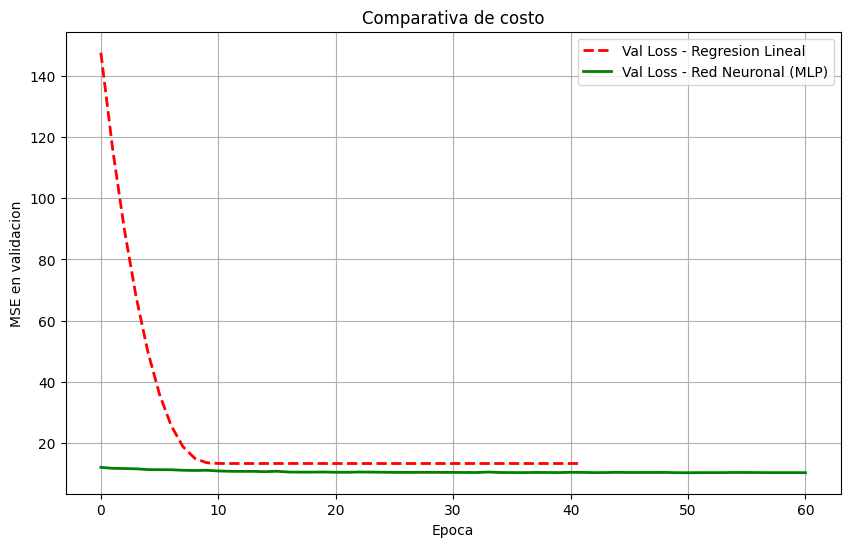

In [32]:
# Grafica desacoplada del entrenamiento: usa los historiales que existan
pyplot.figure(figsize=(10, 6))

if 'J_val_lin' in globals():
    pyplot.plot(
        J_val_lin,
        lw=2,
        color='red',
        linestyle='--',
        label='Val Loss - Regresion Lineal',
    )

if 'J_val_dnn' in globals():
    pyplot.plot(
        J_val_dnn,
        lw=2,
        color='green',
        label='Val Loss - Red Neuronal (MLP)',
    )

pyplot.xlabel('Epoca')
pyplot.ylabel('MSE en validacion')
pyplot.title('Comparativa de costo')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

## Curva de precision del modelo (formula simple tipo costo)

Perfecto: aqui usamos una formula mas simple y con la misma logica de la funcion de costo.

### Costo del modelo en la epoca t
$$J_{modelo}(t)=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-y^{(i)})^2$$

### Costo base (predecir siempre la media)
$$J_{base}=\frac{1}{m}\sum_{i=1}^{m}(\bar{y}-y^{(i)})^2$$

### Precision en porcentaje
$$\mathrm{Precision}(t)=\max\left(0,\,1-\frac{J_{modelo}(t)}{J_{base}+\varepsilon}\right)\times 100$$

Interpretacion:
- Si $J_{modelo}(t)=J_{base}$, precision = 0%.
- Si $J_{modelo}(t)$ baja, la precision sube.
- Si el modelo supera claramente al baseline, la curva sube hacia valores altos.

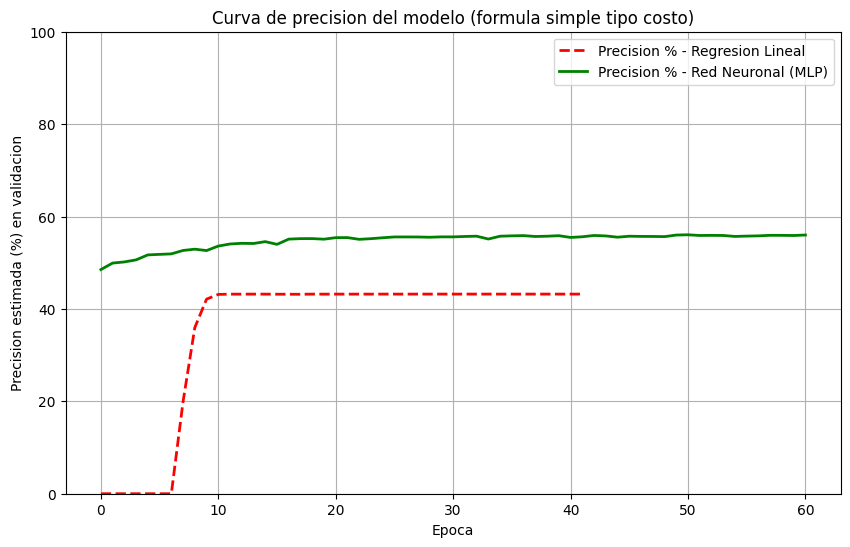

J_base (costo baseline en validacion): 23.445927


In [46]:
# Curva de precision (%) usando una formula simple basada en costos
eps = 1e-8

# 1) Costo base en validacion: predecir siempre la media
y_val_ref = []
with torch.no_grad():
    for _, y_batch in val_loader:
        y_val_ref.append(y_batch.cpu().numpy())
y_val_ref = np.concatenate(y_val_ref).flatten()
y_bar = np.mean(y_val_ref)
J_base = np.mean((y_val_ref - y_bar) ** 2)

def precision_simple_desde_costo(hist_costo, J_base, eps=1e-8):
    hist_costo = np.array(hist_costo, dtype=float)
    if hist_costo.size == 0:
        return hist_costo
    precision = (1.0 - (hist_costo / (J_base + eps))) * 100.0
    return np.clip(precision, 0, 100)

pyplot.figure(figsize=(10, 6))

if 'J_val_lin' in globals() and len(J_val_lin) > 0:
    precision_lin = precision_simple_desde_costo(J_val_lin, J_base, eps)
    pyplot.plot(
        precision_lin,
        lw=2,
        linestyle='--',
        color='red',
        label='Precision % - Regresion Lineal',
    )

if 'J_val_dnn' in globals() and len(J_val_dnn) > 0:
    precision_dnn = precision_simple_desde_costo(J_val_dnn, J_base, eps)
    pyplot.plot(
        precision_dnn,
        lw=2,
        color='green',
        label='Precision % - Red Neuronal (MLP)',
    )

pyplot.xlabel('Epoca')
pyplot.ylabel('Precision estimada (%) en validacion')
pyplot.title('Curva de precision del modelo (formula simple tipo costo)')
pyplot.ylim(0, 100)
pyplot.grid(True)
pyplot.legend()
pyplot.show()

print(f'J_base (costo baseline en validacion): {J_base:.6f}')

## Significado de metricas (marco general antes de validar y testear)

Este bloque resume **como interpretar** las metricas en cualquier celda de evaluacion.

- **MSE**: error cuadratico medio. Si sube mucho, tienes errores grandes frecuentes.
- **RMSE**: error promedio en la misma unidad de la tasa de interes (puntos porcentuales).
- **MAE**: error absoluto promedio, mas estable frente a outliers.
- **R2**: que porcentaje de variabilidad real explica el modelo (mas alto es mejor).
- **MAPE/sMAPE**: error relativo porcentual (util para comunicar impacto proporcional).
- **P50/P90/P95/P99**: cola de errores; si P95/P99 son altos, hay casos criticos mal predichos.
- **Cobertura ±k**: porcentaje de predicciones dentro de una tolerancia (precision operativa).

Regla metodologica del laboratorio:
- Primero se usa **validacion** para diagnostico y ajuste.
- Luego se reporta **test** como resultado final de generalizacion.

In [33]:
# Cuadernillo 4: cargar checkpoint guardado para evaluaciones consistentes (val/test).
# Esta celda NO calcula metricas de test; solo prepara model_eval.
t0_eval_setup = time.time()
best_path = '/kaggle/working/modelo_dnn.pt'
model_eval = RedNeuronal(n_features=N_FEATURES).to(device)
checkpoint = torch.load(best_path, map_location=device)
model_eval.load_state_dict(checkpoint['model_state_dict'])
model_eval.eval()


print('MODELO DE EVALUACION PREPARADO DESDE CHECKPOINT')

print(f"Checkpoint cargado (epoca {checkpoint['epoch']}, val_loss={checkpoint['loss']:.4f})")
print('Siguiente paso: evaluar primero en VALIDACION y luego en TEST final.')
print(f"Tiempo de preparacion: {time.time() - t0_eval_setup:.2f} s")

MODELO DE EVALUACION PREPARADO DESDE CHECKPOINT
Checkpoint cargado (epoca 51, val_loss=10.3047)
Siguiente paso: evaluar primero en VALIDACION y luego en TEST final.
Tiempo de preparacion: 0.02 s


## Evaluacion detallada en VALIDACION (diagnostico para ajuste) - Cuadernillo 2 + 4

Esta celda se ejecuta **antes del test final** para decidir ajustes de hiperparametros.

### Que se analiza aqui
- Error promedio: MSE, RMSE, MAE.
- Calidad global de ajuste: R2, explained variance.
- Error relativo: MAPE, sMAPE.
- Comportamiento de cola: P90/P95/P99.
- Precision operativa por tolerancia: cobertura ±1, ±2, ±4.

Nota: si se muestra `head(100)`, solo es una vista rapida. Las metricas se calculan sobre **toda la validacion**.

In [34]:
import pandas as pd
# Evaluacion detallada en VALIDACION con el mejor checkpoint
eps = 1e-8

if 'model_eval' not in globals():
    model_eval = model
    print('Aviso: model_eval no estaba definido; se usa model actual.')

model_eval.eval()
val_real_list = []
val_pred_list = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model_eval(X_batch)
        val_real_list.append(y_batch.cpu().numpy())
        val_pred_list.append(preds.cpu().numpy())

y_val_real = np.concatenate(val_real_list).flatten()
y_val_pred = np.concatenate(val_pred_list).flatten()
err_abs_val = np.abs(y_val_real - y_val_pred)

# Tabla formal real vs predicho vs error
tabla_val = pd.DataFrame({
    'valor_real': y_val_real,
    'valor_predicho': y_val_pred,
    'error_absoluto': err_abs_val,
})

print(f'Total de ejemplos evaluados en validacion: {len(y_val_real)}')
print('Mostrando solo las primeras 100 filas para inspeccion visual:')
display(tabla_val.head(100))

# Metricas extendidas
mse_val = np.mean((y_val_real - y_val_pred) ** 2)
rmse_val = np.sqrt(mse_val)
mae_val = np.mean(err_abs_val)

ss_res_val = np.sum((y_val_real - y_val_pred) ** 2)
ss_tot_val = np.sum((y_val_real - np.mean(y_val_real)) ** 2)
r2_val = 1 - ss_res_val / (ss_tot_val + eps)

mape_val = np.mean(err_abs_val / np.clip(np.abs(y_val_real), eps, None)) * 100
smape_val = np.mean(
    2 * err_abs_val / (np.abs(y_val_real) + np.abs(y_val_pred) + eps)
) * 100
explained_var_val = 1 - (np.var(y_val_real - y_val_pred) / (np.var(y_val_real) + eps))

p50, p90, p95, p99 = np.percentile(err_abs_val, [50, 90, 95, 99])

cov_1 = np.mean(err_abs_val <= 1.0) * 100
cov_2 = np.mean(err_abs_val <= 2.0) * 100
cov_4 = np.mean(err_abs_val <= 4.0) * 100


print('METRICAS EXTENDIDAS - VALIDACION')

print(f'MSE:               {mse_val:.4f}')
print(f'RMSE:              {rmse_val:.4f}')
print(f'MAE:               {mae_val:.4f}')
print(f'R2:                {r2_val:.4f}')
print(f'MAPE:              {mape_val:.2f}%')
print(f'sMAPE:             {smape_val:.2f}%')
print(f'Explained Variance:{explained_var_val:.4f}')

print(f'P50 error abs:     {p50:.4f}')
print(f'P90 error abs:     {p90:.4f}')
print(f'P95 error abs:     {p95:.4f}')
print(f'P99 error abs:     {p99:.4f}')

print(f'Cobertura ±1.0:    {cov_1:.2f}%')
print(f'Cobertura ±2.0:    {cov_2:.2f}%')
print(f'Cobertura ±4.0:    {cov_4:.2f}%')

Total de ejemplos evaluados en validacion: 172990
Mostrando solo las primeras 100 filas para inspeccion visual:


,valor_real,valor_predicho,error_absoluto
0,15.220000,14.587070,0.632930
1,13.560000,16.010889,2.450889
2,7.890000,11.699337,3.809337
3,17.469999,15.491692,1.978308
4,21.850000,17.646347,4.203653
5,10.150000,13.169155,3.019156
6,10.490000,12.627626,2.137627
7,13.670000,14.800812,1.130812
8,9.440000,9.830562,0.390562
9,12.120000,13.958225,1.838225


METRICAS EXTENDIDAS - VALIDACION
MSE:               10.3047
RMSE:              3.2101
MAE:               2.3873
R2:                0.5605
MAPE:              19.23%
sMAPE:             18.25%
Explained Variance:0.5605
P50 error abs:     1.8249
P90 error abs:     5.1075
P95 error abs:     6.5564
P99 error abs:     10.2237
Cobertura ±1.0:    29.08%
Cobertura ±2.0:    53.84%
Cobertura ±4.0:    82.71%


## Evaluacion final en TEST (100% del test) - Cuadernillo 2 + 4

Esta celda es el **reporte final de generalizacion**: se evalua en todo el conjunto de test no visto.

### Que debe interpretarse aqui
- Estas metricas son las que se reportan como rendimiento final del modelo.
- Si mejoran en validacion pero empeoran en test, hubo sobreajuste.
- La comparacion correcta entre modelos se hace con este bloque final, usando el mismo split y mismo test.

### Relacion con cuadernillos
- Cuadernillo 2: inferencia y metricas de regresion.
- Cuadernillo 4: reutilizacion del mejor checkpoint para evaluar sin reentrenar.

In [35]:
import torch
import numpy as np

# Cuadernillo 4: reutilizamos model_eval desde mejor checkpoint.
# Cuadernillo 2: evaluacion de metricas de regresion en TODO test.
# ── EVALUACION GLOBAL SOBRE TODO EL SET DE TEST (100% DEL TEST) ──
if 'model_eval' not in globals():
    best_path = '/kaggle/working/modelo_dnn.pt'
    model_eval = RedNeuronal(n_features=N_FEATURES).to(device)
    checkpoint = torch.load(best_path, map_location=device)
    model_eval.load_state_dict(checkpoint['model_state_dict'])
    model_eval.eval()
    print(f"model_eval cargado desde checkpoint (epoca {checkpoint['epoch']}, val_loss={checkpoint['loss']:.4f})")

model_eval.eval()
X_tensor = torch.from_numpy(X_test_norm).float().to(device)

with torch.no_grad():
    y_test_pred = model_eval(X_tensor).cpu().numpy().flatten()

# ── CÁLCULO DE MÉTRICAS DE REGRESIÓN ──
mse = np.mean((y_test - y_test_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_test_pred))

# R² (qué tanto explica el modelo la realidad)
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# ── CÁLCULO DE "PRECISIÓN" POR TOLERANCIA ──
margen_estricto = 2.0
margen_flexible = 4.0

diferencias_absolutas = np.abs(y_test - y_test_pred)
aciertos_estrictos = np.sum(diferencias_absolutas <= margen_estricto)
aciertos_flexibles = np.sum(diferencias_absolutas <= margen_flexible)

precision_estricta = (aciertos_estrictos / len(y_test)) * 100
precision_flexible = (aciertos_flexibles / len(y_test)) * 100

# ── REPORTE FINAL ──

print('REPORTE DE RENDIMIENTO (100% DEL TEST NO VISTO)')

print(f'Cantidad total de ejemplos evaluados en test: {len(y_test)}')
print(f'MSE  (Error Cuadratico):        {mse:.4f}')
print(f'RMSE (Error Promedio Real):     ±{rmse:.4f}% en la tasa')
print(f'MAE  (Error Absoluto):          ±{mae:.4f}%')
print(f'R2   (Varianza Explicada):      {r2 * 100:.2f}%')

print('PRECISION DEL MODELO (TASA DE ACIERTOS)')

print(f'Aciertos estrictos (±2 puntos): {precision_estricta:.1f}%')
print(f'Aciertos flexibles (±4 puntos): {precision_flexible:.1f}%')


REPORTE DE RENDIMIENTO (100% DEL TEST NO VISTO)
Cantidad total de ejemplos evaluados en test: 432473
MSE  (Error Cuadratico):        10.3543
RMSE (Error Promedio Real):     ±3.2178% en la tasa
MAE  (Error Absoluto):          ±2.3947%
R2   (Varianza Explicada):      55.92%
PRECISION DEL MODELO (TASA DE ACIERTOS)
Aciertos estrictos (±2 puntos): 53.5%
Aciertos flexibles (±4 puntos): 82.6%


## Interfaz Gradio para inferencia

In [36]:
# Instalamos la librería para crear la interfaz web
!pip install -q gradio

In [39]:
def predecir_interes_interactivo(monto, plazo, ingresos, fico, dti, hipoteca, verificado, historial):
    x_input = mu.copy()

    x_input[columnas_x.index('loan_amnt')] = monto
    x_input[columnas_x.index('term')] = plazo
    x_input[columnas_x.index('annual_inc')] = ingresos
    x_input[columnas_x.index('fico_range_low')] = fico
    x_input[columnas_x.index('dti')] = dti

    x_input[columnas_x.index('home_ownership_MORTGAGE')] = 1 if hipoteca == "SÍ" else 0
    x_input[columnas_x.index('verification_status_Verified')] = 1 if verificado == "SÍ" else 0
    x_input[columnas_x.index('credit_history_years')] = historial

    x_norm = (x_input - mu) / sigma
    x_tensor = torch.from_numpy(x_norm).float().unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prediccion = model(x_tensor).item()

    return f"{prediccion:.2f}%"

In [40]:
import gradio as gr

# Definición de perfiles predeterminados para pruebas rápidas
# Orden: [Monto, Plazo, Ingresos, FICO, DTI, Hipoteca, Verificado, Historial]
perfiles_bancarios = [
    [5000, 36, 25000, 640, 30.5, "NO", "NO", 2],   # Perfil: Riesgo / Recién iniciado
    [15000, 36, 45000, 710, 15.0, "NO", "SÍ", 7],  # Perfil: Estándar estable
    [25000, 60, 65000, 690, 22.0, "SÍ", "SÍ", 12], # Perfil: Consolidación de deuda
    [35000, 36, 110000, 780, 8.0, "SÍ", "SÍ", 18], # Perfil: Cliente Preferencial
    [12000, 36, 95000, 820, 4.5, "SÍ", "SÍ", 25]   # Perfil: Excelente / Bajo Riesgo
]

demo = gr.Interface(
    fn=predecir_interes_interactivo,
    inputs=[
        gr.Slider(1000, 40000, step=500, label="Monto del prestamo (USD)", value=10000),
        gr.Radio([36, 60], label="Plazo del prestamo (Meses)", value=36),
        gr.Number(label="Ingresos anuales brutos (USD)", value=50000),
        gr.Slider(600, 850, step=1, label="Calificacion FICO", value=700),
        gr.Slider(0, 50, step=0.1, label="Relacion Deuda/Ingresos (DTI %)", value=15),
        gr.Dropdown(["SÍ", "NO"], label="Posee hipoteca activa", value="NO"),
        gr.Dropdown(["SÍ", "NO"], label="Ingresos verificados", value="SÍ"),
        gr.Slider(1, 40, step=1, label="Años de historial crediticio", value=10)
    ],
    outputs=gr.Textbox(label="Tasa de interes anual estimada"),
    examples=perfiles_bancarios,
    title="Simulador de Riesgo Crediticio - USFX Systems Engineering",
    description="Analisis de tasas de interes mediante Regresion Lineal Multiple. Seleccione un perfil predeterminado o ajuste los valores manualmente.",
    theme="soft",
    flagging_mode ="never"
)

# El link de share=True te servirá para mostrarle el proyecto a tus docentes o amigos
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://eb848bd15d9504e90f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [41]:
# Guardado de normalizacion
np.save('/kaggle/working/mu_model.npy', mu)
np.save('/kaggle/working/sigma_model.npy', sigma)
print('Guardado exitoso: mu_model.npy, sigma_model.npy')

# Carga de checkpoint del modelo profundo
model_cargado = RedNeuronal(n_features=N_FEATURES).to(device)
checkpoint = torch.load('/kaggle/working/modelo_dnn.pt', map_location=device)
model_cargado.load_state_dict(checkpoint['model_state_dict'])
model_cargado.eval()


print('Checkpoint cargado correctamente')
print(f"Mejor epoca guardada: {checkpoint['epoch']}")
print(f"Mejor loss guardado: {checkpoint['loss']:.4f}")


Guardado exitoso: mu_model.npy, sigma_model.npy
Checkpoint cargado correctamente
Mejor epoca guardada: 51
Mejor loss guardado: 10.3047
